Using uploaded image: 'eyes.jfif'.


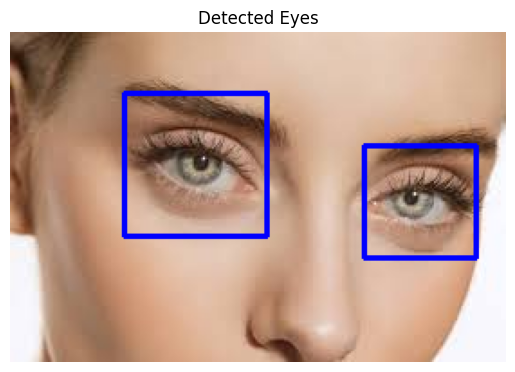

Detected 2 eye(s) in the image.


In [4]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import os # Import os module for path manipulation

# Load the pre-trained eye cascade classifier
# You might need to adjust the path to where your haarcascade_eye.xml file is located
# For example, it might be in an opencv-python installation directory
# or you can download it from OpenCV's GitHub: https://github.com/opencv/opencv/blob/master/data/haarcascades/haarcascade_eye.xml
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

# --- MODIFIED PART: Use uploaded image ---
# The user has indicated that 'eyes.jfif' has been uploaded.
# We will use this file directly.
img_path = 'eyes.jfif'
print(f"Using uploaded image: '{img_path}'.")

# Check if the cascade classifier loaded successfully
if eye_cascade.empty():
    print("Error: Could not load eye cascade classifier. Make sure 'haarcascade_eye.xml' is in the correct path.")
elif img_path is None:
    print("Error: No image file was provided or uploaded.")
else:
    try:
        img = cv2.imread(img_path)

        if img is None:
            # This case might happen if img_path is invalid even after upload
            raise FileNotFoundError(f"Error: Could not read image from {img_path}. It might be corrupted or not a valid image file.")

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Detect eyes in the image
        # Parameters: (image, scaleFactor, minNeighbors)
        # scaleFactor: Specifies how much the image size is reduced at each image scale.
        # minNeighbors: Specifies how many neighbors each candidate rectangle should have to retain it.
        eyes = eye_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

        # Draw rectangles around the detected eyes
        for (x, y, w, h) in eyes:
            cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2) # Blue rectangle, thickness 2

        # Convert BGR image to RGB for displaying with matplotlib
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Display the result
        plt.imshow(img_rgb)
        plt.title('Detected Eyes')
        plt.axis('off') # Hide axes ticks
        plt.show()

        print(f"Detected {len(eyes)} eye(s) in the image.")

    except FileNotFoundError as e:
        print(e)
    except Exception as e:
        print(f"An error occurred: {e}")
